# Is the best of 157 backtests real?

A backtest is a **maximum**, not a sample mean. Nobody reports the first strategy they
tried; they report the best of the several hundred they tried. That makes the reported
Sharpe ratio an order statistic, and the ordinary t-test invalid on it.

This notebook mines 157 strategy variants over sixteen years of SPY, keeps the best one
exactly as any backtester would, and then applies four tests to it — one that knows only
how long the record is, and three that know a search took place. The four disagree about
*how* damning the answer is, which is the point.

Everything here calls the same public functions the library exposes. Nothing is computed
in the notebook that is not computed in the package and covered by a test.

## A note on the data, before anything runs

**No market data is committed to this repository**, and `outputs/` is gitignored — so
there is no CSV waiting for you in the clone. The cell below resolves prices the same way
`luckdet demo` does: **cache, then download, then refuse.**

* If you have run `luckdet demo` or `luckdet mine SPY` before, the cached CSV is found and
  used, and this notebook needs no network.
* If not, it downloads once (needs `pip install -e ".[data]"`) and caches for next time.
* If neither is possible it **raises**, naming `luckdet demo --offline`. It does not fall
  back to generated prices. A quickstart that quietly swapped a random number generator
  for a market while printing the same confident narrative would be committing the exact
  error this package exists to catch.

The outputs below are stored in the file, generated by running this notebook against real
SPY prices. So the numbers are readable on GitHub without running anything, and they are
the same numbers the README quotes — produced by this code path rather than transcribed
into it.

In [1]:
from luckdetector.report.demo import resolve_demo_prices

history = resolve_demo_prices()          # SPY, from 2010-01-01
print(f"{history.symbol}  {history.span}  ({history.source})")
print(f"{history.n_periods:,} daily closes")

SPY  2010-01-04 to 2026-08-07  (cache)
4,174 daily closes


## 1. Mine the grid, keep the winner

Four families — moving-average crossover, momentum, RSI and breakout — expanded into a
157-variant parameter grid, backtested vectorised with a 1bp cost on turnover.

`mine` returns **every** trial, not just the best. That is not generosity: three of the
four tests below are undefined without the losers, and a backtester who keeps only the
survivor has destroyed the evidence needed to judge it.

In [2]:
import numpy as np

from luckdetector.mining import mine
from luckdetector.stats import max_drawdown, sharpe_ratio

result = mine(history.close, cost_bps=1.0)

sharpes = np.array([sharpe_ratio(result.trials.trial(i)) for i in range(result.n_trials)])
best = int(np.argmax(sharpes))
winner = result.trials.trial(best)

print(f"trials mined      {result.n_trials}")
print(f"winner            {result.trials.labels[best]}")
print(f"annualised Sharpe {sharpes[best]:.3f}")
print(f"total return      {winner.total_return():+.1%}")
print(f"max drawdown      {max_drawdown(winner):.1%}")

trials mined      157
winner            MA(80,250)
annualised Sharpe 0.491
total return      +205.6%
max drawdown      -40.3%


That is the result a backtester would publish: a positive Sharpe and a tripling of
capital over sixteen years, from a rule simple enough to fit in a sentence.

## 2. The naive test passes

The Probabilistic Sharpe Ratio asks the *only* question a single track record can answer:
is this record long enough for its Sharpe to be distinguishable from zero, given that
returns are skewed and fat-tailed? It knows nothing about how many strategies were tried.

In [3]:
from luckdetector.stats import min_track_record_length, probabilistic_sharpe_ratio
from luckdetector.stats.psr import PSR_THRESHOLD

psr = probabilistic_sharpe_ratio(winner)
verdict_word = "pass" if psr.passed else "flag"
print(f"PSR vs zero            {psr.psr:.4f}   (threshold {PSR_THRESHOLD} -> {verdict_word})")
print(f"years of record        {psr.n_periods / psr.periods_per_year:.1f}")
print(f"years actually needed  {min_track_record_length(winner) / 252:.1f}")
print()
print(psr.interpretation)

PSR vs zero            0.9764   (threshold 0.95 -> pass)
years of record        16.6
years actually needed  11.4

Given 4,173 observations with skew -0.25 and kurtosis 16.64, there is a 97.6% probability that the true Sharpe ratio exceeds 0.00.


**Read that twice.** A backtester who computed a Probabilistic Sharpe Ratio, got 97.6%,
and stopped would have concluded the record was sound. Everything that follows disagrees,
and the only thing the following tests know that this one does not is that a *search* took
place.

## 3. Deflate it: would the best of N coin flips have looked this good?

The Deflated Sharpe Ratio is the PSR evaluated against a benchmark equal to the Sharpe
you would *expect* from the best of N independent zero-edge trials. `N` is the **effective**
number of trials — 157 variants of four ideas are nowhere near 157 independent bets, and
the correlation is measured rather than assumed.

In [4]:
from luckdetector.stats import deflated_sharpe_ratio_from_trials, sharpe_required_for_dsr
from luckdetector.stats.dsr import DSR_THRESHOLD

dsr = deflated_sharpe_ratio_from_trials(result.trials, index=best)
hurdle = sharpe_required_for_dsr(dsr)
verdict_word = "pass" if dsr.passed else "flag"

print(f"trials run                   {dsr.n_trials}")
print(f"effectively independent      {dsr.n_effective_trials:.0f}")
print(f"expected max Sharpe of noise {dsr.expected_max_sharpe_annual:.3f}")
print(f"winner's Sharpe              {dsr.sharpe_annual:.3f}")
print(f"Deflated Sharpe Ratio        {dsr.dsr:.4f}   (threshold {DSR_THRESHOLD} -> {verdict_word})")
print()
print(f"Sharpe the winner needed     {hurdle:.3f}")
print(f"variants that reach it       {int((sharpes >= hurdle).sum())} of {result.n_trials}")

trials run                   157
effectively independent      12
expected max Sharpe of noise 0.309
winner's Sharpe              0.491
Deflated Sharpe Ratio        0.7692   (threshold 0.95 -> flag)

Sharpe the winner needed     0.715
variants that reach it       0 of 157


The winner **clears** the expected maximum of noise — and so do 43 of the 157 variants.
That comparison is the obvious one to draw and it is not the one the test applies: the
expected maximum is a *point*, while the winner's Sharpe is an *estimate with a standard
error*. Allowing for it, 95% confidence needs a Sharpe of 0.715, which the winner misses
by 0.22 and which nothing in the grid reaches.

## 4. Does the in-sample winner survive out-of-sample?

Combinatorially Symmetric Cross-Validation splits the record into 16 contiguous blocks and
takes every one of the 12,870 ways to use half of them in-sample. In each split it picks
the in-sample best, then asks where that strategy ranks out-of-sample. **PBO is the
fraction of splits where the in-sample winner lands in the bottom half.** Pure noise gives
0.5.

In [5]:
from luckdetector.stats import probability_of_backtest_overfitting

pbo = probability_of_backtest_overfitting(result.trials, n_blocks=16, seed=0)

print(f"splits evaluated              {pbo.n_splits:,}")
print(f"PBO                           {pbo.pbo:.4f}   (noise baseline 0.50)")
print(f"probability of OOS loss       {pbo.probability_of_loss:.4f}")
print(f"stochastic dominance          {pbo.dominance_fraction:.3f}")
print(f"median OOS Sharpe, IS winner  {pbo.median_oos_sharpe_selected:.3f}")
print(f"median OOS Sharpe, random     {float(np.median(pbo.oos_sharpe_random)):.3f}")

splits evaluated              12,870
PBO                           0.8396   (noise baseline 0.50)
probability of OOS loss       0.4407
stochastic dominance          0.973
median OOS Sharpe, IS winner  0.032
median OOS Sharpe, random     0.189


0.84 against a noise baseline of 0.50 means selection here is not merely uninformative,
it is **anti-predictive**: picking the in-sample winner does worse out-of-sample than
picking a variant at random.

## 5. Did any of the 157 beat the thing you could have done instead?

White's Reality Check and Hansen's SPA test one null over the whole family: *no strategy
in it beats the benchmark.* The benchmark is the entire question. Against zero the test
asks "did anything make money"; against buy-and-hold it asks whether running the search
was worth it at all.

In [6]:
from luckdetector.stats import reality_check
from luckdetector import ReturnSeries

buy_and_hold = ReturnSeries(
    result.buy_and_hold, periods_per_year=252, name="buy-and-hold"
)

vs_zero = reality_check(result.trials, 0.0, n_resamples=1000, seed=0)
vs_bh = reality_check(result.trials, buy_and_hold, n_resamples=1000, seed=0)

print(f"vs zero          RC {vs_zero.p_reality_check:.4f}   SPA {vs_zero.p_consistent:.4f}")
print(f"vs buy-and-hold  RC {vs_bh.p_reality_check:.4f}   SPA {vs_bh.p_consistent:.4f}")
print()
print(f"variants beating buy-and-hold: {vs_bh.n_beating_benchmark} of {vs_bh.n_trials}")
print(f"buy-and-hold Sharpe {sharpe_ratio(buy_and_hold):.3f}, total {buy_and_hold.total_return():+.1%}")

vs zero          RC 0.2428   SPA 0.4306
vs buy-and-hold  RC 1.0000   SPA 1.0000

variants beating buy-and-hold: 0 of 157
buy-and-hold Sharpe 0.867, total +814.3%


The same 157 strategies score p = 0.24 against zero and p = 1.00 against buy-and-hold.
Both numbers are true, and a write-up that reports only the first has not stated a single
false thing.

p = 1.0000 here is **not** an overwhelming rejection — it is an empty comparison. The SPA
statistic is `max(0, ...)` and nothing had a positive mean differential, so there was
nothing to test. That is why `TestResult` has a third state, `NOT_APPLICABLE`, rather than
folding it into a pass or a failure: on this family it carries the strongest sentence in
the analysis.

## 6. One answer

The verdict layer takes the four *computed results* and combines them with a transparent
rule table — no composite score, because a weighted average would hide which evidence
drove the answer. Worst flag wins; PSR is a precondition rather than a fourth vote.

In [7]:
from luckdetector import assess

verdict = assess(psr=psr, dsr=dsr, pbo=pbo, spa=vs_bh)

for test in verdict.results:
    print(f"  [{test.status:<15}] {test.name.upper()}")
print()
print(verdict.label)
print()
print(verdict.narrative)

  [PASS           ] PSR
  [FAIL           ] DSR
  [FAIL           ] PBO
  [NOT_APPLICABLE ] SPA

LIKELY_LUCK

LIKELY LUCK — at least one test that knows a search took place objected.

  [PASS] Probabilistic Sharpe Ratio
      Given 4,173 observations with skew -0.25 and kurtosis 16.64, there is a 97.6% probability that the true Sharpe ratio exceeds 0.00.
  [FAIL] Deflated Sharpe Ratio
      Across 157 trials (12.0 effectively independent), the best of pure noise would be expected to post an annualised Sharpe of 0.31. This strategy posted 0.49, giving a 76.9% probability that its edge is real rather than the product of the search.
  [FAIL] Probability of Backtest Overfitting
      Across 12,870 balanced splits of 16 contiguous blocks, the best of 157 trials in-sample fell into the bottom half of the field out-of-sample 84.0% of the time — worse than choosing a strategy at random. Its median out-of-sample Sharpe was 0.03, and it lost money out-of-sample in 44.1% of splits.
  [NOT_APPLICA

`report.analysis.analyse_mined` does all of the above in one call, and is what the CLI and
the HTML report drive. It returns the same verdict, from the same functions.

In [8]:
from luckdetector.report.analysis import analyse_mined

analysis = analyse_mined(result, dates=history.dates, n_resamples=1000)
print(analysis.label, "|", analysis.winner_label, f"{analysis.winner_sharpe:.3f}")

LIKELY_LUCK | MA(80,250) 0.491


## 7. The two pictures

`report.plots` builds figures through matplotlib's object-oriented API and never imports
`pyplot` — a library that uses `pyplot` leaks a figure into a global registry on every
call and picks its backend by sniffing the environment. `%matplotlib inline` below is
what teaches the notebook to render the returned `Figure` objects; it is not what creates
them.

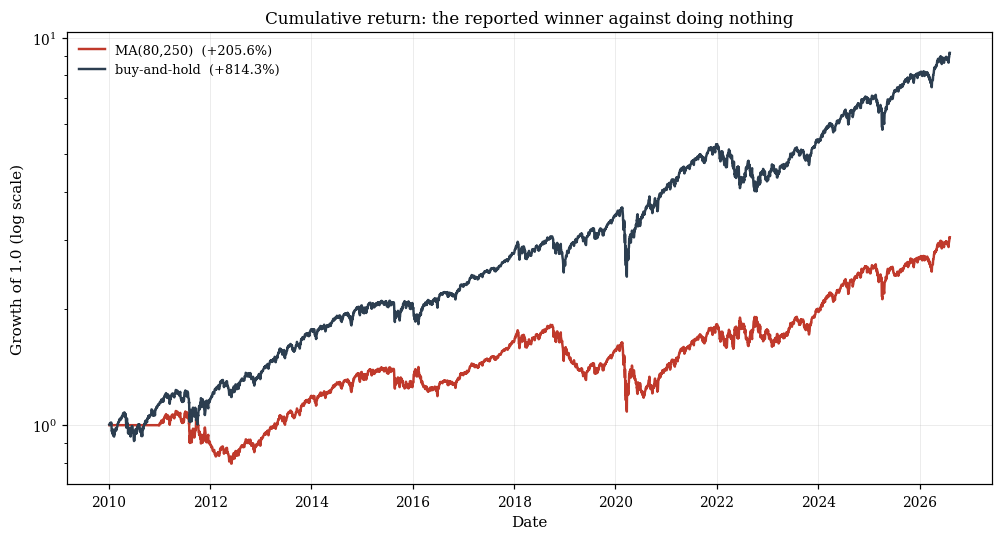

In [9]:
%matplotlib inline
from luckdetector.report.plots import cumulative_return_figure, trial_sharpe_figure

cumulative_return_figure(analysis)

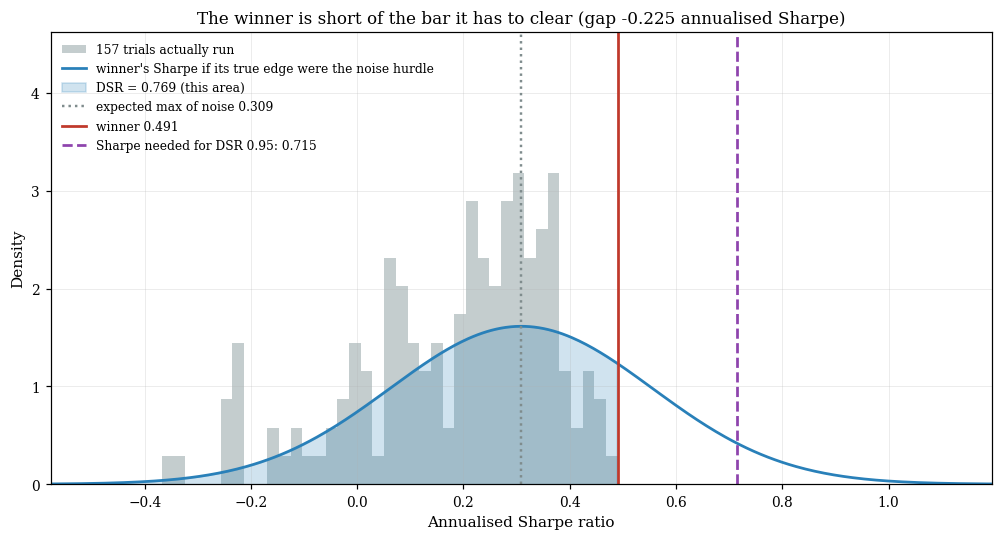

In [10]:
trial_sharpe_figure(analysis)

## 8. It is not a machine that says no

A luck detector that never finds skill is a rubber stamp. The control plants a genuine,
persistent edge in 5 of 50 variants and runs the identical machinery over it.

In [11]:
from luckdetector.report.demo import planted_edge_analysis

control = planted_edge_analysis(n_resamples=1000)
print(control.label)
for test in control.verdict.results:
    print(f"  [{test.status:<15}] {test.name.upper()}")

LIKELY_SKILL
  [PASS           ] PSR
  [PASS           ] DSR
  [PASS           ] PBO
  [PASS           ] SPA


## What would change the conclusion

Four limitations, each measured elsewhere in this project rather than offered as a generic
disclaimer:

1. **The window flatters the benchmark.** 2010–2026 was a historic bull market, and trend
   rules that go flat or short necessarily give up ground in a relentless uptrend. This is
   evidence about *this* family over *this* window, not a verdict on trend following.
2. **PBO has no purge or embargo.** The CSCV blocks are contiguous with no gap between the
   in-sample and out-of-sample halves, so a 250-day-lookback rule is contaminated near each
   seam. That makes the winner look *more* persistent than it is, so the true PBO is likely
   worse than 0.84, not better.
3. **A luck verdict is weak evidence of absence.** Across 25 independent datasets, a real
   annualised Sharpe of 2.0 planted in 10 of 50 variants over five years is called
   LIKELY_SKILL only **20%** of the time. This instrument is far better at catching luck
   than at certifying skill, and the asymmetry is deliberate.
4. **The combination rules are invented.** The four statistics each come from a published
   result and are checked against simulation. The rule table that turns them into one label
   is not — there is no literature on weighing a Deflated Sharpe Ratio against a PBO.

`docs/BLUEPRINT.md` has the specification, the citations, and a plainly-marked list of every
place a threshold is a judgement call rather than a convention.

Point `mine()` at your own price series and judge your own backtests. The tool has no
stake in the answer.